In [1]:
import mg5qs_import as qs
from pathlib import Path 

In [2]:
LHE = Path('/home/leo/MadStats/mg5qs/output/cledq__3332_SM_small/Events/run_01/unweighted_events.lhe')
result, four_momenta, status = qs.generate_vals(15, LHE)


 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.311      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change:  8 Mar 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 26 Feb 2025 at 12:10:44    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

In [3]:
import pandas as pd

In [4]:
df_stat = pd.DataFrame(status, columns = result['fields'].split(','))
df_mom = pd.DataFrame(four_momenta, columns=['px','py','pz','E','lhe_pT'])
df = pd.concat([df_stat, df_mom], axis=1)
df

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT
0,1,357,-23,0,1,275,0,-24,90,359,...,15,22,1,1,0,-38.718484,1.632769,15.042479,41.607942,37.182772
1,1,359,-51,0,1,357,0,15,90,645,...,16,-211,0,1,1,-38.718001,1.632782,15.042299,41.607428,37.182772
2,2,906,-23,0,1,686,0,-24,90,1508,...,16,-14,0,1,0,9.632810,-13.467712,-11.081760,20.003335,16.620099
3,3,684,-23,0,1,523,0,-24,90,1200,...,16,-12,0,1,0,-17.839485,-10.276628,-37.145464,42.506465,31.504855
4,4,284,-23,0,1,214,0,-24,90,286,...,15,22,1,1,0,11.577248,-33.624927,-15.780309,38.946685,34.916394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14125,9997,959,-51,0,1,957,0,15,90,1771,...,16,-211,0,1,1,-26.129851,6.980008,-35.197777,44.424439,37.007937
14126,9998,488,-23,0,1,366,0,-24,90,490,...,15,22,1,1,0,-6.748104,12.241616,-5.724415,15.209231,13.774763
14127,9998,490,-51,0,1,488,0,15,90,924,...,16,-211,0,1,1,-6.748249,12.241435,-5.724457,15.209166,13.774763
14128,9999,109,-23,0,1,81,0,-24,90,247,...,16,-211,0,1,0,-19.751698,31.305360,-152.082924,156.532835,37.862058


In [5]:
dup_event = df['EVENT'].value_counts()>1 # events with more than 1 tau
df_dup = df[df['EVENT'].isin(dup_event[dup_event].index)] # details about such taus
df_dup

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT
0,1,357,-23,0,1,275,0,-24,90,359,...,15,22,1,1,0,-38.718484,1.632769,15.042479,41.607942,37.182772
1,1,359,-51,0,1,357,0,15,90,645,...,16,-211,0,1,1,-38.718001,1.632782,15.042299,41.607428,37.182772
4,4,284,-23,0,1,214,0,-24,90,286,...,15,22,1,1,0,11.577248,-33.624927,-15.780309,38.946685,34.916394
5,4,286,-51,0,1,284,0,15,90,550,...,16,-12,0,1,1,11.577248,-33.624927,-15.780309,38.946685,34.916394
11,10,1020,-23,0,1,782,0,-24,90,1022,...,15,22,1,1,0,-19.703766,-11.171150,10.457534,25.011012,22.077771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14121,9994,573,-51,0,1,571,0,15,90,907,...,16,-12,0,1,1,55.900261,-0.500461,0.844850,55.937118,33.955931
14124,9997,957,-23,0,1,718,0,-24,90,959,...,15,22,1,1,0,-26.129857,6.980010,-35.197786,44.424451,37.007937
14125,9997,959,-51,0,1,957,0,15,90,1771,...,16,-211,0,1,1,-26.129851,6.980008,-35.197777,44.424439,37.007937
14126,9998,488,-23,0,1,366,0,-24,90,490,...,15,22,1,1,0,-6.748104,12.241616,-5.724415,15.209231,13.774763


In [6]:
df_dup['EVENT'].shape, df_dup['EVENT'].unique().shape

((7667,), (3537,))

In [7]:
df['MOTHER1ID'].abs().value_counts() #abs of particle for all imeadite par

MOTHER1ID
24     9875
15     4042
431      71
1        54
2        43
4        15
3        13
511       5
521       5
411       4
531       3
Name: count, dtype: int64

In [8]:
df['STATUS'].value_counts()

STATUS
-23    10000
-51     3455
-44      449
-62      125
-91       85
-52       13
-92        3
Name: count, dtype: int64

In [9]:
df['ISFINAL'].sum()

np.int64(0)

Investagae daughters (if daughter1=daughter2>0 => carbon copy of .this):

In [11]:
df_cc = df[df['DAUGHTER1']==df['DAUGHTER2']]
df_cc

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT
38,30,5,-23,0,1,3,4,1,-2,9,...,15,15,1,1,0,-10.598916,-7.012125,15.253155,19.932972,12.708537
39,30,9,-44,0,1,5,5,15,15,14,...,15,15,1,1,1,1.235908,-2.862311,29.653833,29.870183,12.708537
40,30,14,-44,0,1,9,9,15,15,35,...,15,15,1,1,2,1.521426,-7.949770,30.086103,31.206488,12.708537
41,30,35,-44,0,1,14,14,15,15,68,...,15,15,1,1,3,1.516906,-7.937491,30.129379,31.244871,12.708537
52,38,5,-23,0,1,3,4,1,-2,9,...,15,15,1,1,0,-66.638545,22.075132,219.445326,230.407066,70.199766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13780,9740,60,-44,0,1,36,36,15,15,72,...,15,15,1,1,5,53.791005,49.843219,100.011552,124.029380,51.736105
13781,9740,72,-44,0,1,60,60,15,15,215,...,15,15,1,1,6,54.264308,50.327092,102.037274,126.064247,51.736105
13898,9830,5,-23,0,1,3,4,1,-2,42,...,15,15,1,1,0,-0.260963,12.650704,-25.236357,28.286744,12.653395
13899,9830,42,-44,0,1,5,5,15,15,108,...,15,15,1,1,1,-3.644125,12.167647,-24.762409,27.886662,12.653395


In [12]:
df['EVENT'].value_counts()

EVENT
4761     12
7142     12
3479     10
6073     10
5477     10
         ..
3540      1
3537      1
10000     1
9999      1
9996      1
Name: count, Length: 10000, dtype: int64

In [13]:
df[df['EVENT']==2425]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT
3418,2425,5,-23,0,1,3,4,3,-4,21,...,15,15,1,1,0,-27.794325,-47.045536,0.996289,54.680502,54.642538
3419,2425,21,-44,0,1,5,5,15,15,66,...,15,15,1,1,1,-28.550363,-47.640235,0.100767,55.568724,54.642538
3420,2425,66,-44,0,1,21,21,15,15,76,...,15,15,1,1,2,-26.036478,-49.359575,-0.117656,55.834017,54.642538
3421,2425,76,-44,0,1,66,66,15,15,602,...,15,15,1,1,3,-25.910733,-48.807292,0.440147,55.288962,54.642538
3422,2425,602,-62,0,1,76,76,15,15,1450,...,16,-211,0,1,4,-26.159860,-48.504580,0.409250,55.139439,54.642538


In [14]:
df[df['EVENT']==2873]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT
4049,2873,5,-23,0,1,3,4,1,-2,9,...,15,15,1,1,0,-19.535176,-39.460210,82.629090,93.645371,44.031026
4050,2873,9,-44,0,1,5,5,15,15,17,...,15,15,1,1,1,-11.924661,-55.325453,83.147606,100.597144,44.031026
4051,2873,17,-44,0,1,9,9,15,15,24,...,15,15,1,1,2,-10.956551,-56.766145,86.759985,104.273170,44.031026
4052,2873,24,-44,0,1,17,17,15,15,94,...,15,15,1,1,3,-10.863849,-57.919996,90.320119,107.859310,44.031026
4053,2873,94,-44,0,1,24,24,15,15,324,...,15,15,1,1,4,-11.050483,-57.692790,90.386303,107.811932,44.031026
4054,2873,324,-62,0,1,94,94,15,15,789,...,16,-14,0,1,5,-10.991477,-57.677142,90.581239,107.961029,44.031026


In [15]:
df[df['DUPLICATED']==0].shape

(10088, 21)

In [16]:
df.shape

(14130, 21)

We want to find all events with more than 1 unique tau (i.e. not in the same chain). We will do this by finding the events for which the number of taus exceeds the number of duplicates by more than 1 (every chain will terminate with duplicate=0, so we must have **more** than 1 chain termination).

In [17]:
A = df['EVENT'].value_counts() # numbers of taus per event
B = df[df['DUPLICATED']==True]['EVENT'].value_counts() # number duplicates per event
a,b = A.align(B) # alligns a and b (order and shape) 
a[(a-b.fillna(0))>1] # events for which non-duplicates exceeds 1 (more than 1 chain)

EVENT
70      3
76      2
91      2
201     2
258     2
       ..
8519    2
8667    2
9158    3
9353    2
9546    3
Name: count, Length: 88, dtype: int64

In [18]:
df[df['EVENT']==120]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT
164,120,418,-23,0,1,309,0,-24,90,845,...,16,-12,0,1,0,-12.128735,-38.212585,139.855706,145.49943,39.627534


In [19]:
df[df['CHAIN']>2]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT


In [20]:
df[df['EVENT']==5900]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT
8364,5900,250,-23,0,1,191,0,-24,90,252,...,15,22,1,1,0,27.106787,-4.319787,-54.897091,61.40266,28.679661
8365,5900,252,-51,0,1,250,0,15,90,451,...,16,-12,0,1,1,27.106787,-4.319787,-54.897091,61.40266,28.679661


We can inquire about the lhe_level cut by slicing the lhe_pT column. First, I will compute the pT of each, post-shower, particle for sake of comparison.

In [25]:
import numpy as np

In [28]:
df['pT'] = np.sqrt((df['px']**2)+(df['py']**2))

In [29]:
df[df['lhe_pT']>100]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT,pT
2712,1936,5,-23,0,1,3,4,-2,1,9,...,15,1,1,0,6.993979,-114.570747,-36.238672,120.381771,114.784022,114.784022
2713,1936,9,-44,0,1,5,5,15,15,14,...,15,1,1,1,-18.331176,-147.946923,-26.979747,151.510358,114.784022,149.078248
2714,1936,14,-44,0,1,9,9,15,15,20,...,15,1,1,2,48.632492,-152.727065,-38.610406,164.877521,114.784022,160.283111
2715,1936,20,-44,0,1,14,14,15,15,54,...,15,1,1,3,50.563876,-155.455384,-41.818042,168.745336,114.784022,163.471961
2716,1936,54,-44,0,1,20,20,15,15,456,...,15,1,1,4,51.388388,-155.875290,-41.493053,169.300631,114.784022,164.127610
2717,1936,456,-44,0,1,54,54,15,15,732,...,15,1,1,5,51.393163,-156.055895,-41.715081,169.522876,114.784022,164.300638
2718,1936,732,-62,0,1,456,456,15,15,1557,...,-211,0,1,6,51.818490,-155.954322,-42.155968,169.667881,114.784022,164.337781


In this case, there is only a single event which passes a 100GeV cut at the lhe-level. As we can see, the pT of each daughter actually increaces as a result of each showing step. This appears to counter the prior result that onlt some small fraction of particle increace pT after showering. 

Also notebale is that the pT at the first step in showing mathes exactly that reported in the lhe. In fact, this is not the trend, each first particle in the shower has pT unrelated to that which is contained in the lhe (sometimes higher, lower, or in the above case, the same). What exactly this means about how Pythia is attributing addational energy to particles, I am unsure. 

In [37]:
df[(df['EVENT']<12) & (df['CHAININDEX']==0)] # look at the first 12 first particles

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT,pT
0,1,357,-23,0,1,275,0,-24,90,359,...,22,1,1,0,-38.718484,1.632769,15.042479,41.607942,37.182772,38.752896
2,2,906,-23,0,1,686,0,-24,90,1508,...,-14,0,1,0,9.632810,-13.467712,-11.081760,20.003335,16.620099,16.558088
3,3,684,-23,0,1,523,0,-24,90,1200,...,-12,0,1,0,-17.839485,-10.276628,-37.145464,42.506465,31.504855,20.587771
4,4,284,-23,0,1,214,0,-24,90,286,...,22,1,1,0,11.577248,-33.624927,-15.780309,38.946685,34.916394,35.562176
6,5,527,-23,0,1,396,0,-24,90,1000,...,-211,0,1,0,-30.420049,53.941050,-13.307447,63.366096,39.920606,61.927508
7,6,1251,-23,0,1,954,0,-24,90,2125,...,211,0,1,0,-12.821916,22.946337,129.933519,132.577574,28.411922,26.285660
8,7,206,-23,0,1,148,0,-24,90,443,...,211,0,1,0,33.029798,8.864050,45.886546,57.256195,30.324540,34.198522
9,8,760,-23,0,1,574,0,-24,90,1364,...,-211,0,1,0,15.879666,47.710048,-53.409344,73.376619,33.172955,50.283322
10,9,136,-23,0,1,104,0,-24,90,266,...,-12,0,1,0,-18.182364,9.151952,3.662856,20.758874,15.173273,20.355751
11,10,1020,-23,0,1,782,0,-24,90,1022,...,22,1,1,0,-19.703766,-11.171150,10.457534,25.011012,22.077771,22.650231


I can draw the distribution of the diffrence in pT-lhe_pT to get some notion of how this changes on averadge (being carefull to exclude those 1% addational backgroud taus, since they are unrelated to the tau in the lhe). 

In [40]:
import matplotlib.pyplot as plt

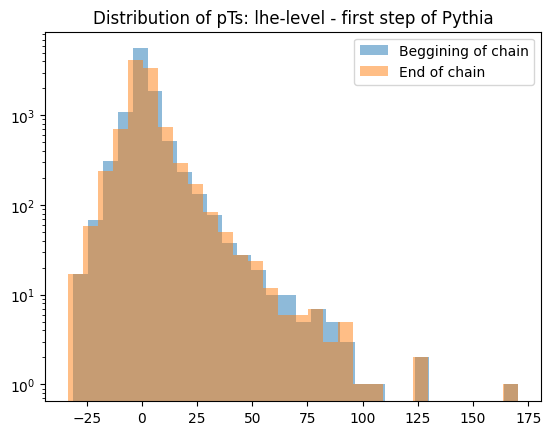

In [64]:
df['pT_diff'] =  df['pT'] - df['lhe_pT']
first_particles = (df['CHAININDEX']==0) & (df['CHAIN']==1)
plt.hist(df[first_particles]['pT_diff'], alpha=.5, label='Beggining of chain', bins=30)
last_particles = (df['DUPLICATED']==0) & (df['CHAIN']==1)
plt.hist(df[last_particles]['pT_diff'], alpha=.5, label='End of chain', bins=30)
plt.legend()
plt.title('Distribution of pTs: lhe-level - first step of Pythia')
plt.yscale('log')
plt.show()

In [57]:
df[df['pT_diff']>130]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT,pT,pT_diff
9032,6374,329,-23,0,1,255,0,-24,90,610,...,0,1,0,129.1438,-157.066826,-97.240194,225.403908,32.738119,203.342344,170.604225


In [59]:
df[df['EVENT']==6374]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,lhe_pT,pT,pT_diff
9032,6374,329,-23,0,1,255,0,-24,90,610,...,0,1,0,129.1438,-157.066826,-97.240194,225.403908,32.738119,203.342344,170.604225


Very strange event..